In [122]:
# ============================================================
# GENERATIVE ADVERSARIAL NETWORK (GAN)
# MNIST IMAGE GENERATION
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


In [123]:
# ============================================================
# STEP 2: LOAD MNIST DATASET
# ============================================================

from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("MNIST dataset loaded successfully!")

print("\nTraining images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("\nTesting images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

MNIST dataset loaded successfully!

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)

Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


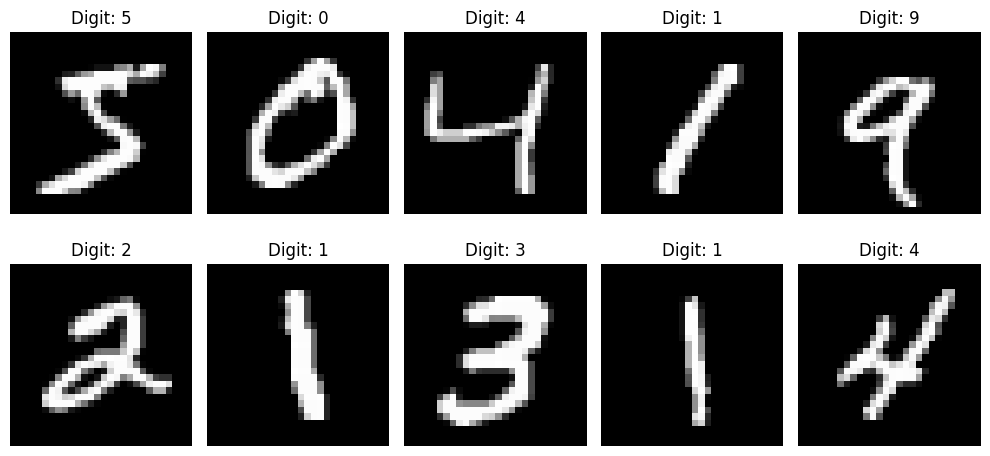

In [124]:
# ============================================================
# STEP 3: VISUALIZE REAL MNIST IMAGES
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [125]:
# ============================================================
# STEP 4: NORMALIZE IMAGES
# ============================================================

X_train = X_train.astype("float32")

# Normalize pixel values from [0, 255] to [-1, 1]
X_train = (X_train - 127.5) / 127.5

print("Normalization completed!")

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Normalization completed!
Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [126]:
# ============================================================
# STEP 5: ADD CHANNEL DIMENSION
# ============================================================

X_train = X_train[..., np.newaxis]

print("New training image shape:", X_train.shape)

New training image shape: (60000, 28, 28, 1)


In [127]:
# ============================================================
# STEP 6: CREATE TRAINING DATASET
# ============================================================

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

print("TensorFlow training dataset created!")
print("Batch size:", BATCH_SIZE)

TensorFlow training dataset created!
Batch size: 256


In [128]:
# ============================================================
# STEP 7: BUILD GENERATOR
# ============================================================

def build_generator():

    model = tf.keras.Sequential([

        # Input: random noise vector
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Reshape into feature maps
        layers.Reshape((7, 7, 256)),

        # Upsample: 7x7 -> 14x14
        layers.Conv2DTranspose(
            128,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample: 14x14 -> 28x28
        layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Final image: 28x28x1
        layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=1,
            padding="same",
            activation="tanh"
        )
    ])

    return model


generator = build_generator()

print("Generator created successfully!")

Generator created successfully!


In [129]:
# ============================================================
# STEP 8: GENERATOR SUMMARY
# ============================================================

generator.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [130]:
# ============================================================
# STEP 9: TEST GENERATOR
# ============================================================

noise = tf.random.normal([1, 100])

generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


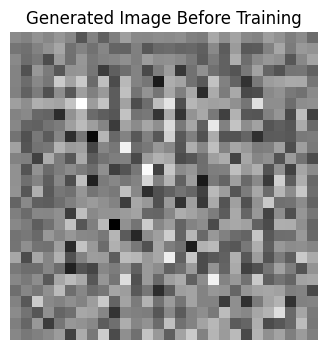

In [131]:
# ============================================================
# STEP 10: VISUALIZE GENERATED IMAGE BEFORE TRAINING
# ============================================================

plt.figure(figsize=(4, 4))

plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)

plt.title("Generated Image Before Training")
plt.axis("off")

plt.show()

In [132]:
# ============================================================
# STEP 11: BUILD DISCRIMINATOR
# ============================================================

def build_discriminator():

    model = tf.keras.Sequential([

        # Input: 28x28 grayscale image
        layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=[28, 28, 1]
        ),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        # Second convolution
        layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        ),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        # Flatten
        layers.Flatten(),

        # Output probability
        layers.Dense(1)
    ])

    return model


discriminator = build_discriminator()

print("Discriminator created successfully!")

Discriminator created successfully!


In [133]:
# ============================================================
# STEP 12: DISCRIMINATOR SUMMARY
# ============================================================

discriminator.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [134]:
# ============================================================
# STEP 13: TEST DISCRIMINATOR
# ============================================================

real_image = X_train[0]

# Add batch dimension
real_image = real_image[np.newaxis, ...]

prediction = discriminator(
    real_image,
    training=False
)

print("Discriminator output:", prediction.numpy())

Discriminator output: [[0.01717144]]


In [135]:
# ============================================================
# STEP 14: DEFINE GAN LOSS FUNCTION
# ============================================================

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

print("Binary cross-entropy loss created successfully!")

Binary cross-entropy loss created successfully!


In [136]:
# ============================================================
# STEP 15: DISCRIMINATOR LOSS
# ============================================================

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

In [137]:
# ============================================================
# STEP 16: GENERATOR LOSS
# ============================================================

def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [138]:
# ============================================================
# STEP 17: CREATE OPTIMIZERS
# ============================================================

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [139]:
# ============================================================
# STEP 18: TRAINING CONFIGURATION
# ============================================================

EPOCHS = 30
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16

# Fixed random seed for generating images
seed = tf.random.normal(
    [NUM_EXAMPLES_TO_GENERATE, NOISE_DIM]
)

print("Training configuration:")
print("Epochs:", EPOCHS)
print("Noise dimension:", NOISE_DIM)
print("Images generated per checkpoint:", NUM_EXAMPLES_TO_GENERATE)

Training configuration:
Epochs: 30
Noise dimension: 100
Images generated per checkpoint: 16


In [140]:
# ============================================================
# STEP 19: GAN TRAINING STEP
# ============================================================

@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update model weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

print("GAN training step created successfully!")

GAN training step created successfully!


In [141]:
# ============================================================
# STEP 21: GAN TRAINING LOOP
# ============================================================

def train_gan(dataset, epochs):

    print("GAN training started...\n")

    for epoch in range(1, epochs + 1):

        start = time.time()

        generator_losses = []
        discriminator_losses = []

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch
            )

            generator_losses.append(
                gen_loss.numpy()
            )

            discriminator_losses.append(
                disc_loss.numpy()
            )

        avg_gen_loss = np.mean(generator_losses)
        avg_disc_loss = np.mean(discriminator_losses)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f} | "
            f"Time: {time.time() - start:.2f}s"
        )

        # Display generated images every 5 epochs
        if epoch % 5 == 0 or epoch == 1:

            generate_and_save_images(
                generator,
                epoch,
                seed
            )

    print("\nGAN training completed!")

In [142]:
# ============================================================
# STEP 22A: CREATE FAST TRAINING DATASET
# ============================================================

BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)

train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Fast training dataset created!")
print("Batch size:", BATCH_SIZE)

Fast training dataset created!
Batch size: 128


In [143]:
# ============================================================
# STEP 22B: REDUCE TRAINING EPOCHS
# ============================================================

EPOCHS = 10

print("Training epochs:", EPOCHS)

Training epochs: 10


In [144]:
# ============================================================
# STEP 22C: CHECK GPU
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected!")
    print(gpus)
else:
    print("No GPU detected. Training is using CPU.")

No GPU detected. Training is using CPU.


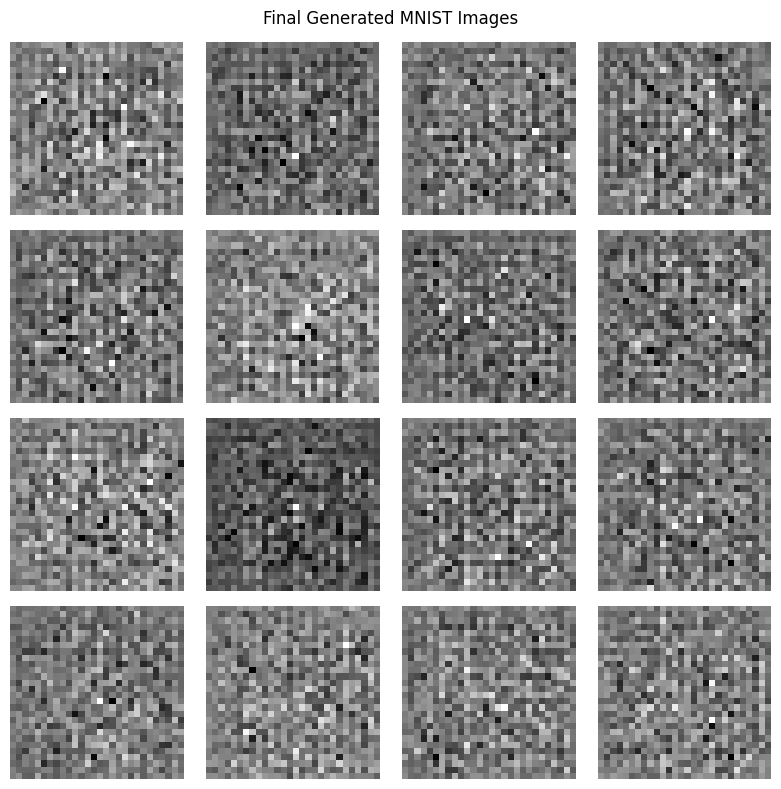

Final images generated successfully!


In [145]:
# ============================================================
# GENERATE FINAL IMAGES FROM TRAINED GAN
# ============================================================

final_noise = tf.random.normal(
    [16, NOISE_DIM]
)

final_images = generator(
    final_noise,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        final_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Final Generated MNIST Images")
plt.tight_layout()
plt.show()

print("Final images generated successfully!")

In [148]:
# ============================================================
# STEP 23 - SAVE TRAINED GENERATOR
# ============================================================

generator.save("mnist_gan_generator.keras")

print("Generator model saved successfully!")
print("File: mnist_gan_generator.keras")

Generator model saved successfully!
File: mnist_gan_generator.keras


In [149]:
# ============================================================
# STEP 24 - LOAD SAVED GENERATOR AND GENERATE NEW IMAGES
# ============================================================

from tensorflow.keras.models import load_model

saved_generator = load_model("mnist_gan_generator.keras")

print("Saved Generator loaded successfully!")

Saved Generator loaded successfully!


In [150]:
# Generate new random noise
new_noise = tf.random.normal([16, NOISE_DIM])

# Generate new MNIST images
new_images = saved_generator(
    new_noise,
    training=False
)

print("New images generated successfully!")
print("Generated images shape:", new_images.shape)

New images generated successfully!
Generated images shape: (16, 28, 28, 1)


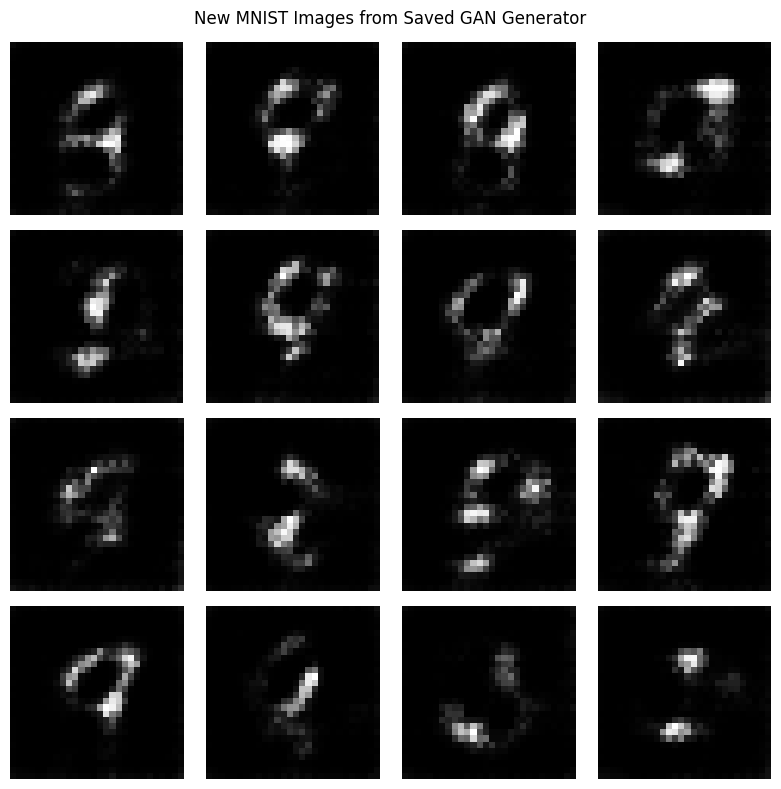

In [151]:
# ============================================================
# DISPLAY NEW GENERATED IMAGES
# ============================================================

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        new_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("New MNIST Images from Saved GAN Generator")
plt.tight_layout()
plt.show()

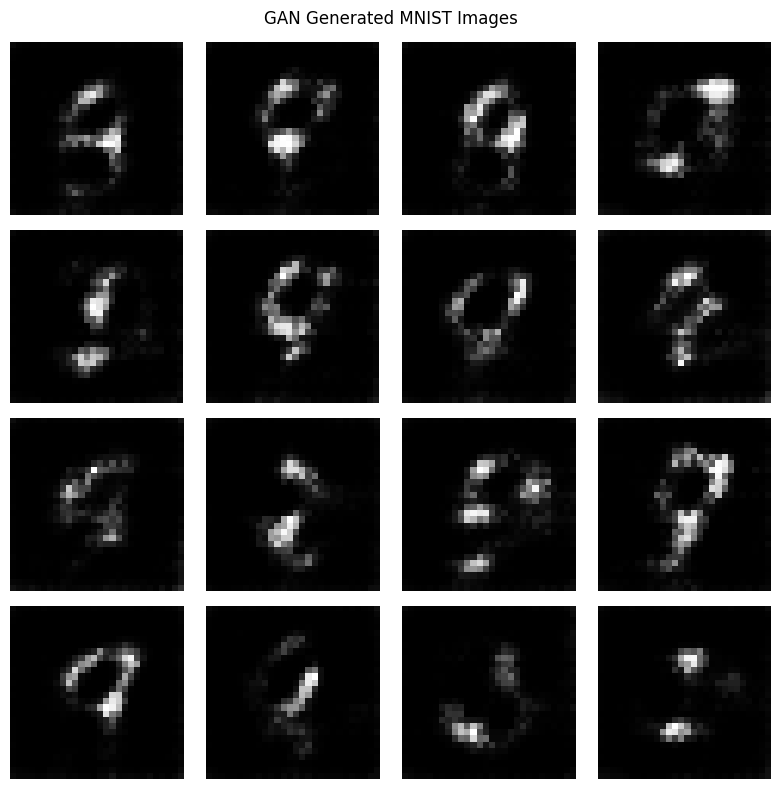

Generated images saved successfully!
File: gan_generated_mnist.png


In [152]:
# ============================================================
# STEP 25 - SAVE GENERATED IMAGES
# ============================================================

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        new_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("GAN Generated MNIST Images")
plt.tight_layout()

plt.savefig(
    "gan_generated_mnist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Generated images saved successfully!")
print("File: gan_generated_mnist.png")

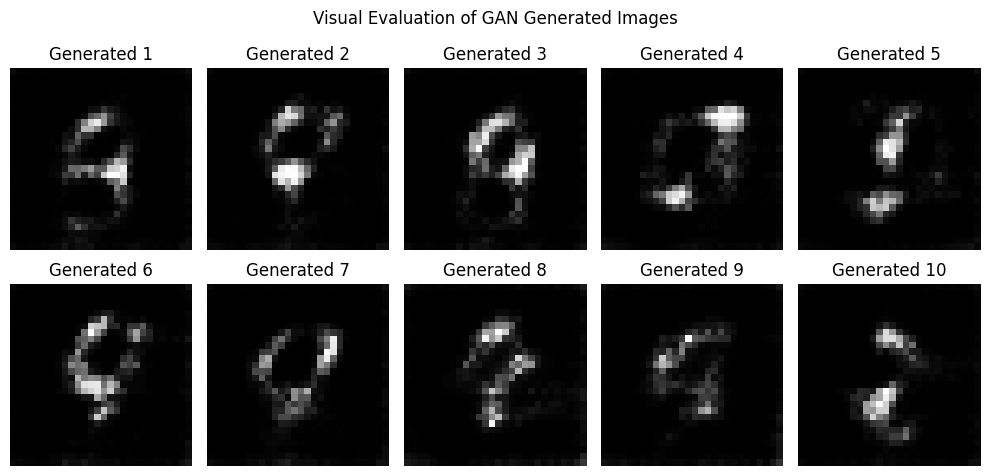

Visual evaluation completed!


In [153]:
# ============================================================
# STEP 26 - VISUAL EVALUATION OF GENERATED IMAGES
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        new_images[i, :, :, 0] * 127.5 + 127.5,
        cmap="gray"
    )

    plt.title(f"Generated {i + 1}")
    plt.axis("off")

plt.suptitle("Visual Evaluation of GAN Generated Images")
plt.tight_layout()
plt.show()

print("Visual evaluation completed!")

In [154]:
# ============================================================
# STEP 27 - FINAL PROJECT RESULTS
# ============================================================

print("=" * 55)
print("       GENERATIVE ADVERSARIAL NETWORK - RESULTS")
print("=" * 55)

print("\nDataset: MNIST")
print("Image Size: 28 x 28")
print("Image Type: Grayscale")
print("Training Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Noise Dimension:", NOISE_DIM)

print("\nGenerator:")
generator.summary()

print("\nDiscriminator:")
discriminator.summary()

print("\nFinal generated images:", new_images.shape)
print("\nModel file: mnist_gan_generator.keras")
print("Generated image file: gan_generated_mnist.png")

print("\nGAN project completed successfully!")

       GENERATIVE ADVERSARIAL NETWORK - RESULTS

Dataset: MNIST
Image Size: 28 x 28
Image Type: Grayscale
Training Epochs: 10
Batch Size: 128
Noise Dimension: 100

Generator:


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


Final generated images: (16, 28, 28, 1)

Model file: mnist_gan_generator.keras
Generated image file: gan_generated_mnist.png

GAN project completed successfully!


In [155]:
# ============================================================
# STEP 28 - CREATE REQUIREMENTS FILE
# ============================================================

requirements = """tensorflow
numpy
matplotlib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [156]:
# ============================================================
# STEP 29 - CHECK PROJECT FILES
# ============================================================

import os

print("Project files:")

for file in os.listdir():
    if file in [
        "mnist_gan_generator.keras",
        "gan_generated_mnist.png",
        "requirements.txt"
    ]:
        print("✓", file)

Project files:
✓ requirements.txt
✓ mnist_gan_generator.keras
✓ gan_generated_mnist.png


In [157]:
# ============================================================
# STEP 30 - DOWNLOAD PROJECT FILES
# ============================================================

from google.colab import files

files.download("mnist_gan_generator.keras")
files.download("gan_generated_mnist.png")
files.download("requirements.txt")

print("Download commands executed successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download commands executed successfully!


In [146]:
# ============================================================
# FIX: GENERATE AND DISPLAY IMAGES
# ============================================================

def generate_and_save_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.tight_layout()
    plt.show()

print("Image generation function created successfully!")

Image generation function created successfully!


In [147]:
# ============================================================
# STEP 22D: START FAST GAN TRAINING
# ============================================================

train_gan(train_dataset, EPOCHS)

GAN training started...



KeyboardInterrupt: 